# Sparsity study 

TODO:
- fix bootstrap
- run boostrap
- check if we want to re-run algo after finding the sparsity matrix (instead of sparsifying as epochs go by), maybe order 2
- add TCTC section and study the temporal attention matrices
- check with a sparsity with shift_cs? maybe not necessary but interesting

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV, RidgeCV, LinearRegression
import torch
from torch.utils.data import Dataset, random_split
from torch.utils.data import DataLoader
import importlib
import sys
sys.path.append('/Users/cyrilgarcia/notebooks/tsnn/')

import tsnn

from tsnn.generators import generators
from tsnn import tstorch
from tsnn.benchmarks import benchmark_comparison, ml_benchmarks, torch_benchmarks
from tsnn import utils
from tsnn.tstorch import transformers
import torch.nn.functional as F
import math
from typing import Optional

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor

from torch import nn
from tqdm import tqdm
device = 'mps'


plt.style.use('ggplot')

In [2]:
from dataclasses import dataclass

@dataclass
class Config:
    T: int = 5000
    n_ts: int = 10
    n_f: int = 20
    pct_zero_corr: float = 0.5
    split_conditional: float = 0.0
    split_shift: float = 1.0
    split_seasonal: float = 0.0
    split_cs: float = 0.0
    split_cs_shift: float = 0.0
    low_corr: float = 0.05
    high_corr: float = 0.1

In [3]:
z = generators.Generator(Config.T, Config.n_ts, Config.n_f)

In [4]:
%%time
z.generate_dataset(pct_zero_corr = Config.pct_zero_corr,
                  split_conditional = Config.split_conditional,
                  split_shift = Config.split_shift,
                  split_seasonal = Config.split_seasonal,
                  split_cs=Config.split_cs,
                  split_cs_shift=Config.split_cs_shift,
                  low_corr=Config.low_corr, 
                  high_corr=Config.high_corr)

CPU times: user 17 ms, sys: 2.8 ms, total: 19.8 ms
Wall time: 21 ms


In [5]:
z.get_dataloader(n_rolling=10)

In [6]:
def causal_mask(b, h, q_idx, kv_idx):
    return q_idx >= kv_idx

def causal_mask_radius(b, h, q_idx, kv_idx):
    return (q_idx >= kv_idx) & (q_idx <= kv_idx+1)

def plot_mask(mask_fn, seq_len=20, title=None, device="cpu"):
    """
    Plot a binary attention mask defined by mask_fn(b,h,q_idx,kv_idx)
    as a (seq_len x seq_len) matrix.
    """
    q_idx = torch.arange(seq_len, device=device)
    kv_idx = torch.arange(seq_len, device=device)
    b = torch.zeros(1, device=device) 
    h = torch.zeros(1, device=device)

    mask = mask_fn(b, h, q_idx[:, None], kv_idx[None, :])
    mask = mask.float().cpu()

    return pd.DataFrame(mask).style.background_gradient(axis=None).format(precision=0)

def build_attention_mask(mask_fn, seq_len, device="cpu"):
    q_idx = torch.arange(seq_len, device=device)
    kv_idx = torch.arange(seq_len, device=device)
    b = torch.zeros(1, device=device)
    h = torch.zeros(1, device=device)
    mask_bool = mask_fn(b, h, q_idx[:, None], kv_idx[None, :])  # (seq_len, seq_len)
    return mask_bool


In [7]:
mask_fn = causal_mask
plot_mask(mask_fn, seq_len=5)

,0,1,2,3,4
0,1,0,0,0,0
1,1,1,0,0,0
2,1,1,1,0,0
3,1,1,1,1,0
4,1,1,1,1,1


In [8]:
mask_fn = causal_mask_radius
plot_mask(mask_fn, seq_len=5)

,0,1,2,3,4
0,1,0,0,0,0
1,1,1,0,0,0
2,0,1,1,0,0
3,0,0,1,1,0
4,0,0,0,1,1


In [9]:
from tsnn.tstorch import models

In [10]:
models_linear = {'lasso': ml_benchmarks.LassoBenchmark()}

In [11]:
def causal_mask(b, h, q_idx, kv_idx):
    return q_idx >= kv_idx

mask = causal_mask
mask = build_attention_mask(mask, 10, device=device)

In [12]:
def keep_topk_per_row(x, k=3):
    vals, idx = torch.topk(x, k=k, dim=-1, largest=True)
    out = torch.zeros_like(x)
    out.scatter_(-1, idx, 1)
    return out

In [13]:
def keep_by_max_value(x, k=3, frac=0.1):
    row_max = x.max(dim=-1, keepdim=True).values
    threshold = frac * row_max
    out = (x >= threshold).to(x.dtype)
    return out

## List of models

Tried and shown below, I only use a TC model (time + cross sectionnal) and 1 head to make everything simple. I look at a noisy setup of the temporal shift effect.
- Full attention matrix
- Top k coefficients per row of the attention matrix
- Including gated coefficients on each matrix diagonal to get the best MSE while maximizing the sparsity of the attention matrix
- After studying the attention matrix found by the full model, decided to use a method based on the max value of each row to clean the matrix (intuitive since this is a probability space)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:15<00:00,  1.30it/s]


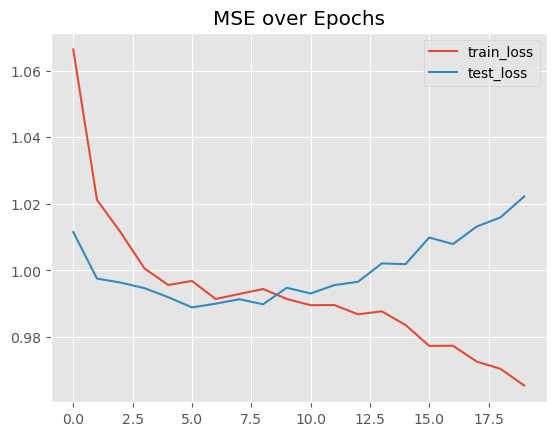

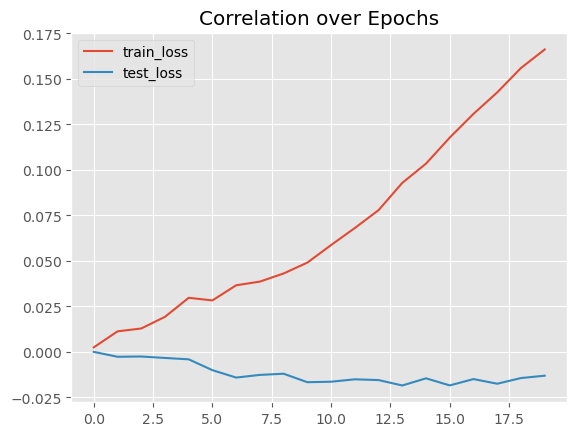

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:14<00:00,  1.38it/s]


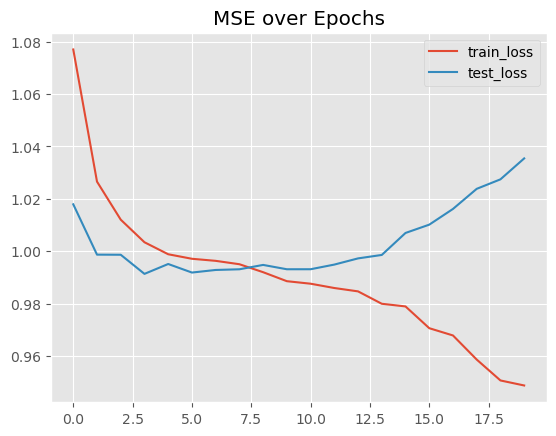

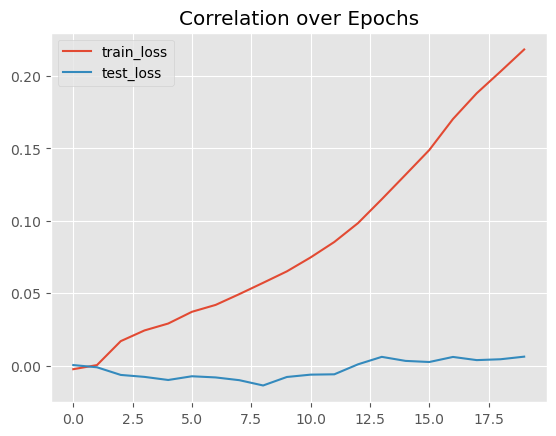

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:14<00:00,  1.34it/s]


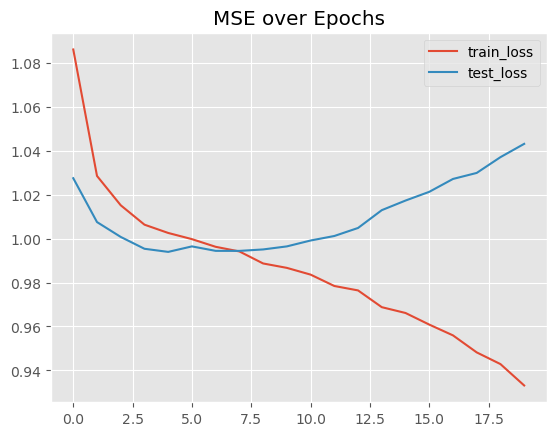

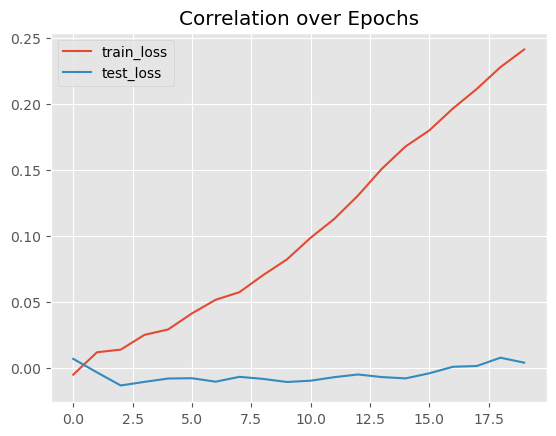

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:15<00:00,  1.31it/s]


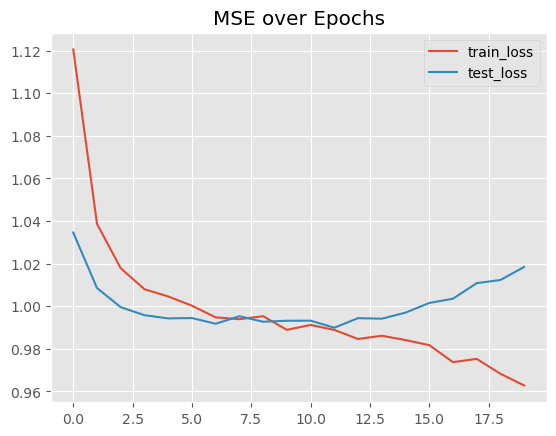

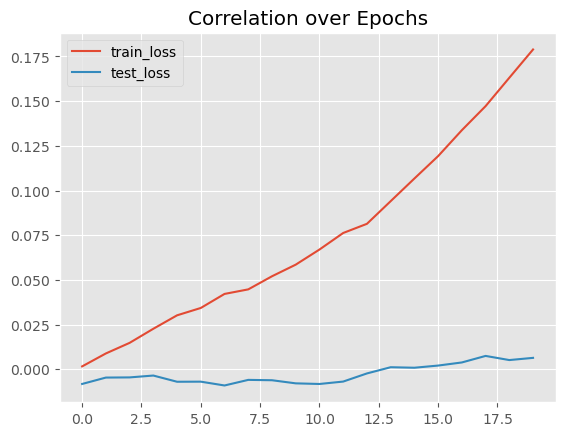

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:18<00:00,  1.10it/s]


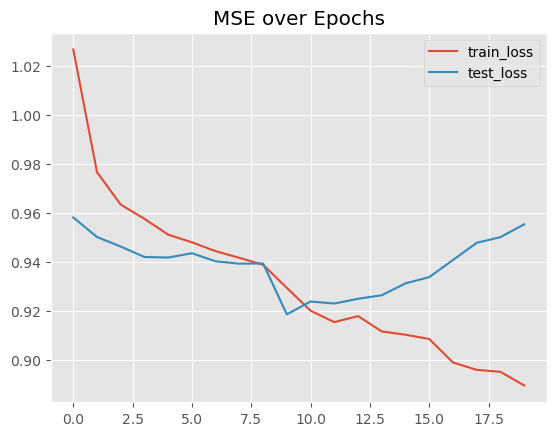

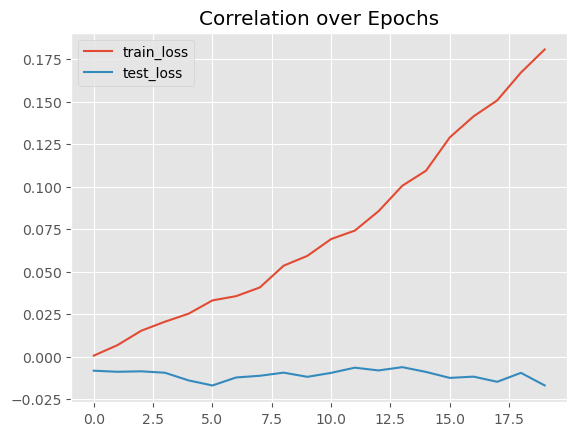

Gated coefficients for sparse model:
Layer 0: [0.         0.14937653 0.         0.14214404 0.13981006 0.
 0.1424716  0.14276639 0.14216498 0.14126645]


,true,optimal,shift,lasso,full_attention,deterministic_sparse,top_k_sparse,max_sparse
optimal,0.031,nan,nan,nan,nan,nan,nan,nan
shift,0.031,1.000,nan,nan,nan,nan,nan,nan
lasso,0.027,-0.002,-0.002,nan,nan,nan,nan,nan
full_attention,0.190,0.007,0.007,0.178,nan,nan,nan,nan
deterministic_sparse,0.257,0.200,0.200,0.134,0.227,nan,nan,nan
top_k_sparse,0.289,0.200,0.200,0.085,0.237,0.359,nan,nan
max_sparse,0.215,0.246,0.246,0.195,0.278,0.379,0.315,nan
dynamic_sparse,0.205,0.023,0.023,0.188,0.345,0.229,0.242,0.307


,true,optimal,shift,lasso,full_attention,deterministic_sparse,top_k_sparse,max_sparse
optimal,0.026,nan,nan,nan,nan,nan,nan,nan
shift,0.026,1.000,nan,nan,nan,nan,nan,nan
lasso,-0.012,0.006,0.006,nan,nan,nan,nan,nan
full_attention,-0.013,0.027,0.027,0.181,nan,nan,nan,nan
deterministic_sparse,-0.003,0.205,0.205,0.135,0.202,nan,nan,nan
top_k_sparse,0.007,0.215,0.215,0.087,0.219,0.287,nan,nan
max_sparse,0.013,0.268,0.268,0.197,0.261,0.339,0.277,nan
dynamic_sparse,-0.005,0.034,0.034,0.191,0.324,0.200,0.206,0.270


In [14]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 10, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 10, device=device)


for c in [0.01]:
    @dataclass
    class Config:
        T: int = 3000
        n_ts: int = 10
        n_f: int = 20
        pct_zero_corr: float = 0.5
        split_conditional: float = 0.0
        split_shift: float = 1.0
        split_seasonal: float = 0.0
        split_cs: float = 0.0
        split_cs_shift: float = 0.0
        low_corr: float = c
        high_corr: float = c
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr
    )
    
    z.get_dataloader()
    for k in models_linear:
        models_linear[k].fit(z.train)
    
    # param for regularization
    lambda_l1_value = 0.5
    
    sparse_model = models.CustomBiDimensionalTransformerSparse(
        Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC',
        dropout=0.1, dim_feedforward=256, sparsify=None, nhead=1,
        lambda_l1=lambda_l1_value, roll_y=True
    ).to(device)
    
    # loss fct with l1 norm
    loss_fn = MSELossWithL1Sparsity(model=sparse_model, lambda_l1=lambda_l1_value)
    
    models_torch = {
        'full_attention': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        'deterministic_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        
        'top_k_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
        ).to(device),
        
        'max_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
        ).to(device),
        
        'dynamic_sparse': sparse_model,
    }


    models_torch = {
        k: torch_benchmarks.TorchWrapper(
            models_torch[k], 
            optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
            loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss()  # Use L1 loss for sparse model
        ) for k in models_torch
    }

    
    z.get_dataloader(n_rolling=10, roll_y=True)
    for k in models_torch:
        models_torch[k].fit(z.train, test=z.test, epochs=20)
    
    # gated coefs print
    print("Gated coefficients for sparse model:")
    gated_coeffs = models_torch['dynamic_sparse'].model.get_gated_coeffs()
    for i, coeffs in enumerate(gated_coeffs):
        print(f"Layer {i}: {coeffs.detach().cpu().numpy()}")
    
    comp = benchmark_comparison.Comparator(
        models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch], 
        model_names=[k for k in models_linear] + [k for k in models_torch]
    )
    display(comp.correl(z, mode='train'))
    display(comp.correl(z, mode='test'))

Full attention matrix

In [15]:
pd.DataFrame(np.array(models_torch['full_attention'].model.blocks[0].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.335,0.665,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.314,0.515,0.171,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.172,0.214,0.497,0.117,0.000,0.000,0.000,0.000,0.000,0.000
4,0.137,0.085,0.240,0.504,0.035,0.000,0.000,0.000,0.000,0.000
5,0.058,0.316,0.159,0.099,0.149,0.218,0.000,0.000,0.000,0.000
6,0.081,0.068,0.262,0.042,0.159,0.207,0.181,0.000,0.000,0.000
7,0.074,0.038,0.035,0.083,0.028,0.277,0.419,0.047,0.000,0.000
8,0.069,0.101,0.066,0.138,0.031,0.076,0.371,0.089,0.061,0.000
9,0.128,0.065,0.062,0.021,0.056,0.085,0.038,0.187,0.314,0.042


Sparsity matrix with the max proba algorithm

In [16]:
pd.DataFrame(np.array(models_torch['max_sparse'].model.blocks[0].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.586,0.414,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.640,0.360,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.000,0.000,0.742,0.258,0.000,0.000,0.000,0.000,0.000,0.000
4,0.000,0.000,0.000,0.603,0.397,0.000,0.000,0.000,0.000,0.000
5,0.000,0.000,0.000,0.000,0.573,0.427,0.000,0.000,0.000,0.000
6,0.000,0.000,0.000,0.000,0.000,0.573,0.427,0.000,0.000,0.000
7,0.000,0.000,0.000,0.000,0.000,0.000,0.685,0.315,0.000,0.000
8,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.648,0.352,0.000
9,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.600,0.400


Preliminary conclusions:
- dynamic sparse seems to find the right coefficients but doesn't show a high improvement over the full attention. also there are some choices here of loss functions etc which may not be optimal
- the 2 sparse methods seem better than full and (expected) right below the informed model where we enforce the correct sparsity
- max_sparse is more stable (to confirm in bootstrap)

## Results bootstrapping

In [44]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 10, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 10, device=device)


records_train = []
records_test  = [] 

for k in range(10):
    records_train.append({})
    records_test.append({})
    
    @dataclass
    class Config:
        T: int = 3000
        n_ts: int = 10
        n_f: int = 20
        pct_zero_corr: float = 0.5
        split_conditional: float = 0.0
        split_shift: float = 1.0
        split_seasonal: float = 0.0
        split_cs: float = 0.0
        split_cs_shift: float = 0.0
        low_corr: float = c
        high_corr: float = c
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr
    )
    
    z.get_dataloader()
    for k in models_linear:
        models_linear[k].fit(z.train)
    
    # param for regularization
    lambda_l1_value = 0.5
    
    sparse_model = models.CustomBiDimensionalTransformerSparse(
        Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC',
        dropout=0.1, dim_feedforward=256, sparsify=None, nhead=1,
        lambda_l1=lambda_l1_value, roll_y=True
    ).to(device)
    
    # loss fct with l1 norm
    loss_fn = MSELossWithL1Sparsity(model=sparse_model, lambda_l1=lambda_l1_value)
    
    models_torch = {
        'full_attention': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        'deterministic_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        
        'top_k_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
        ).to(device),
        
        'max_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
        ).to(device),
        
        'dynamic_sparse': sparse_model,
    }


    models_torch = {
        k: torch_benchmarks.TorchWrapper(
            models_torch[k], 
            optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
            loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss()  
        ) for k in models_torch
    }

    
    z.get_dataloader(n_rolling=10, roll_y=True)
    for k in models_torch:
        models_torch[k].fit(z.train, test=z.test, epochs=20, plot=False)
        
        comp = benchmark_comparison.Comparator(models=[models_torch[k]], model_names=[k])

        
        corr_train = comp.correl(z, mode="train", return_values=True)
        corr_test  = comp.correl(z, mode="test",  return_values=True)

        train_corr = corr_train.loc[k, "optimal"]
        test_corr  = corr_test.loc[k, "optimal"]

        records_train[-1][k + '_train_corr'] = train_corr
        records_test[-1][k + '_test_corr'] = test_corr
        
    
    
    comp = benchmark_comparison.Comparator(
        models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch], 
        model_names=[k for k in models_linear] + [k for k in models_torch]
    )
    display(comp.correl(z, mode='train'))
    display(comp.correl(z, mode='test'))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:15<00:00,  1.28it/s]


,true,optimal,shift,lasso,full_attention,deterministic_sparse,top_k_sparse,max_sparse
optimal,0.032,nan,nan,nan,nan,nan,nan,nan
shift,0.032,1.000,nan,nan,nan,nan,nan,nan
lasso,0.015,0.001,0.001,nan,nan,nan,nan,nan
full_attention,0.253,0.026,0.026,0.080,nan,nan,nan,nan
deterministic_sparse,0.317,0.203,0.203,0.059,0.256,nan,nan,nan
top_k_sparse,0.274,0.204,0.204,0.071,0.261,0.327,nan,nan
max_sparse,0.268,0.243,0.243,0.066,0.278,0.350,0.364,nan
dynamic_sparse,0.286,0.147,0.147,0.084,0.283,0.295,0.286,0.335


,true,optimal,shift,lasso,full_attention,deterministic_sparse,top_k_sparse,max_sparse
optimal,0.058,nan,nan,nan,nan,nan,nan,nan
shift,0.058,1.000,nan,nan,nan,nan,nan,nan
lasso,-0.002,-0.007,-0.007,nan,nan,nan,nan,nan
full_attention,0.011,0.052,0.052,0.072,nan,nan,nan,nan
deterministic_sparse,0.018,0.204,0.204,0.071,0.180,nan,nan,nan
top_k_sparse,0.012,0.219,0.219,0.084,0.206,0.288,nan,nan
max_sparse,0.016,0.243,0.243,0.073,0.247,0.284,0.330,nan
dynamic_sparse,0.005,0.147,0.147,0.087,0.217,0.255,0.252,0.295


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:15<00:00,  1.26it/s]


,true,optimal,shift,lasso,full_attention,deterministic_sparse,top_k_sparse,max_sparse
optimal,0.044,nan,nan,nan,nan,nan,nan,nan
shift,0.044,1.000,nan,nan,nan,nan,nan,nan
lasso,0.036,-0.005,-0.005,nan,nan,nan,nan,nan
full_attention,0.300,0.172,0.172,0.136,nan,nan,nan,nan
deterministic_sparse,0.291,0.229,0.229,0.132,0.345,nan,nan,nan
top_k_sparse,0.281,0.184,0.184,0.155,0.364,0.354,nan,nan
max_sparse,0.319,0.191,0.191,0.161,0.401,0.380,0.329,nan
dynamic_sparse,0.253,0.168,0.168,0.174,0.340,0.336,0.350,0.335


...

,true,optimal,shift,full_attention,deterministic_sparse,top_k_sparse,max_sparse
optimal,0.029,nan,nan,nan,nan,nan,nan
shift,0.029,1.000,nan,nan,nan,nan,nan
full_attention,0.294,0.045,0.045,nan,nan,nan,nan
deterministic_sparse,0.278,0.126,0.126,0.291,nan,nan,nan
top_k_sparse,0.318,0.144,0.144,0.316,0.337,nan,nan
max_sparse,0.298,0.183,0.183,0.332,0.324,0.347,nan
dynamic_sparse,0.234,0.021,0.021,0.299,0.290,0.302,0.304


,true,optimal,shift,full_attention,deterministic_sparse,top_k_sparse,max_sparse
optimal,0.025,nan,nan,nan,nan,nan,nan
shift,0.025,1.000,nan,nan,nan,nan,nan
full_attention,0.008,0.038,0.038,nan,nan,nan,nan
deterministic_sparse,-0.005,0.109,0.109,0.233,nan,nan,nan
top_k_sparse,-0.012,0.156,0.156,0.250,0.269,nan,nan
max_sparse,0.002,0.159,0.159,0.266,0.262,0.302,nan
dynamic_sparse,0.004,0.008,0.008,0.253,0.257,0.250,0.263


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:15<00:00,  1.27it/s]


,true,optimal,shift,lasso,full_attention,deterministic_sparse,top_k_sparse,max_sparse
optimal,0.041,nan,nan,nan,nan,nan,nan,nan
shift,0.041,1.000,nan,nan,nan,nan,nan,nan
lasso,0.017,0.013,0.013,nan,nan,nan,nan,nan
full_attention,0.267,0.126,0.126,0.083,nan,nan,nan,nan
deterministic_sparse,0.320,0.172,0.172,0.063,0.274,nan,nan,nan
top_k_sparse,0.246,0.238,0.238,0.095,0.331,0.326,nan,nan
max_sparse,0.277,0.239,0.239,0.111,0.281,0.313,0.366,nan
dynamic_sparse,0.221,0.023,0.023,0.151,0.293,0.226,0.243,0.286


,true,optimal,shift,lasso,full_attention,deterministic_sparse,top_k_sparse,max_sparse
optimal,0.028,nan,nan,nan,nan,nan,nan,nan
shift,0.028,1.000,nan,nan,nan,nan,nan,nan
lasso,-0.004,0.004,0.004,nan,nan,nan,nan,nan
full_attention,-0.003,0.121,0.121,0.062,nan,nan,nan,nan
deterministic_sparse,0.013,0.190,0.190,0.081,0.219,nan,nan,nan
top_k_sparse,0.007,0.225,0.225,0.063,0.275,0.274,nan,nan
max_sparse,0.008,0.217,0.217,0.106,0.212,0.247,0.317,nan
dynamic_sparse,0.003,0.018,0.018,0.134,0.242,0.156,0.204,0.227


In [46]:
table_train = pd.DataFrame(records_train)
table_test  = pd.DataFrame(records_test)

In [48]:
display(pd.concat([table_test.quantile([0.1, 0.9]), table_test.aggregate(['min', 'max', 'mean', 'std'])]).T.style.background_gradient().format(precision=4))

,0.100000,0.900000,min,max,mean,std
full_attention_test_corr,0.0474,0.1819,0.0388,0.2143,0.1016,0.0601
deterministic_sparse_test_corr,0.1005,0.2582,0.0748,0.2589,0.1813,0.0655
top_k_sparse_test_corr,0.1060,0.2280,0.1038,0.2521,0.1801,0.0488
max_sparse_test_corr,0.1408,0.2542,0.1278,0.2972,0.1963,0.0544
dynamic_sparse_test_corr,0.0082,0.1523,0.0033,0.1733,0.0618,0.0630


In [50]:
display(pd.concat([table_train.quantile([0.1, 0.9]), table_train.aggregate(['min', 'max', 'mean', 'std'])]).T.style.background_gradient().format(precision=4))

,0.100000,0.900000,min,max,mean,std
full_attention_train_corr,0.0485,0.1783,0.0283,0.2241,0.1056,0.0612
deterministic_sparse_train_corr,0.1172,0.2417,0.0743,0.2481,0.1798,0.0592
top_k_sparse_train_corr,0.0983,0.2309,0.0911,0.2374,0.1777,0.0506
max_sparse_train_corr,0.1380,0.2488,0.1377,0.2764,0.1961,0.0502
dynamic_sparse_train_corr,0.0224,0.1445,0.0102,0.1630,0.0667,0.0557


In [22]:
############# BOOTSRAP CODE HAS AN ISSUE NEED TO FIX

In [19]:
# Global parameters
T_max = 3000
N1 = 10
F1 = 20
T1 = 10 # This parameter will be the n_rolling

In [20]:
def make_gen(split_conditional=0.0,
                 split_shift=0.0,
                 split_seasonal=0.0,
                 split_cs=0.0,
                 split_cs_shift=0.0):
        gen = generators.Generator(num_time_steps, num_time_series, num_features)
        gen.generate_dataset(
            pct_zero_corr=pct_zero_corr,
            split_conditional=split_conditional,
            split_shift=split_shift,
            split_seasonal=split_seasonal,
            split_cs=split_cs,
            split_cs_shift=split_cs_shift,
            low_corr=low_corr,
            high_corr=high_corr,
        )
        return gen

def bootstrap_sparsity(noise_level='correl0.03', effect='d_all', n=4):

    # Storage
    records_train = []
    records_test  = []  
    print(f"Running → {noise_level} | {effect}")

    @dataclass
    class Config:
        T: int = 3000
        n_ts: int = 10
        n_f: int = 20
        pct_zero_corr: float = 0.5
        split_conditional: float = 0.0
        split_shift: float = 1.0
        split_seasonal: float = 0.0
        split_cs: float = 0.0
        split_cs_shift: float = 0.0
        low_corr: float = c
        high_corr: float = c
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr
    )
    

    lr=0.001
    roll_y=True

    epochs = 20
    

    for k in tqdm(range(n)):
        z.get_dataloader(n_rolling=T1, roll_y=True)
        roll_y=True
        epochs = 20
        lr=0.0001

        full = models.CustomBiDimensionalTransformer(N1, F1, T1, mask=mask_c, layers='TC',
                                                dropout=0.1, dim_feedforward=256, sparsify=None, 
                                                                           roll_y=roll_y).to(device)

        topk = models.CustomBiDimensionalTransformer(N1, F1, T1, mask=mask_c, layers='TC',
                                                dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, 
                                                                            roll_y=roll_y).to(device)
        
        keep_max = models.CustomBiDimensionalTransformer(N1, F1, T1, mask=mask_c, layers='TC',
                                                dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, 
                                                                            roll_y=roll_y).to(device)
        
        deterministic = models.CustomBiDimensionalTransformer(N1, F1, T1, mask=mask_1, layers='TC',
                                                dropout=0.1, dim_feedforward=256, sparsify=None, 
                                                                            roll_y=roll_y).to(device)
        
        models_torch = {'full': full, 'deterministic': deterministic, 'topk': topk, 'keep_max': keep_max}
        
        
        records_train.append({})
        records_test.append({})
        
        for s in models_torch:
            optimizer = torch.optim.AdamW(models_torch[s].parameters(), lr=lr)
            wrapper = torch_benchmarks.TorchWrapper(models_torch[s], optimizer=optimizer, device=device)
            # Train
            wrapper.fit(z.train, test=z.test, epochs=epochs, plot=False, verbose=0)

            # Compare
            comp = benchmark_comparison.Comparator(models=[wrapper], model_names=[s])

            corr_train = comp.correl(z, mode="train", return_values=True)
            corr_test  = comp.correl(z, mode="test",  return_values=True)

            train_corr = corr_train.loc[s, "optimal"]
            test_corr  = corr_test.loc[s, "optimal"]
            
            records_train[-1][s + '_train_corr'] = train_corr
            records_test[-1][s + '_test_corr'] = test_corr

    # ————————————————————————————————————————
    # 3. Convert to nice DataFrames
    # ————————————————————————————————————————
    df_train = pd.DataFrame(records_train)
    df_test  = pd.DataFrame(records_test)

    return df_train, df_test

In [21]:
table_train, table_test = bootstrap_sparsity(noise_level='correl0.01', effect='d_shift', n=5)
display(pd.concat([table_test.quantile([0.1, 0.9]), table_test.aggregate(['min', 'max', 'mean', 'std'])]).T.rename_axis(effect, axis=0).style.background_gradient().format(precision=4))

Running → correl0.01 | d_shift


 20%|██████████████████████                                                                                        | 1/5 [01:40<06:41, 100.44s/it]


KeyboardInterrupt: 

## More complex models wiht shift effect

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:27<00:00,  1.39s/it]


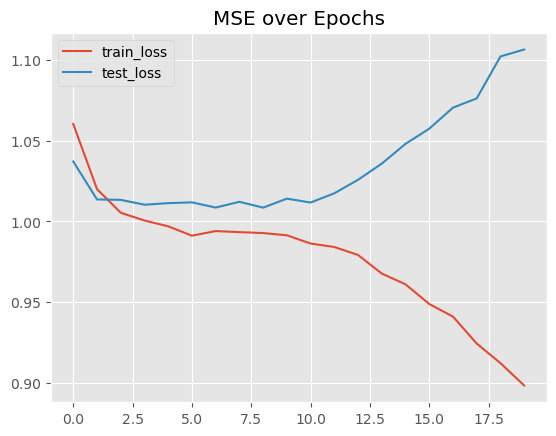

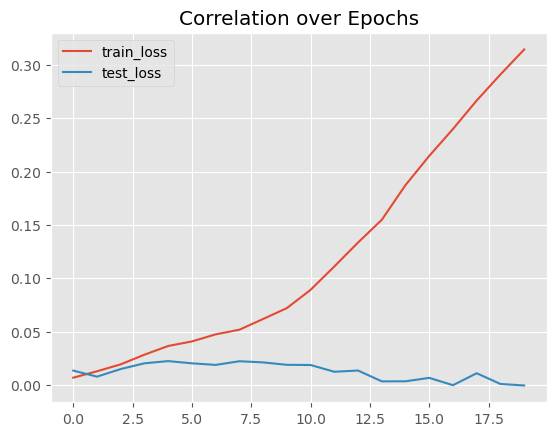

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:28<00:00,  1.41s/it]


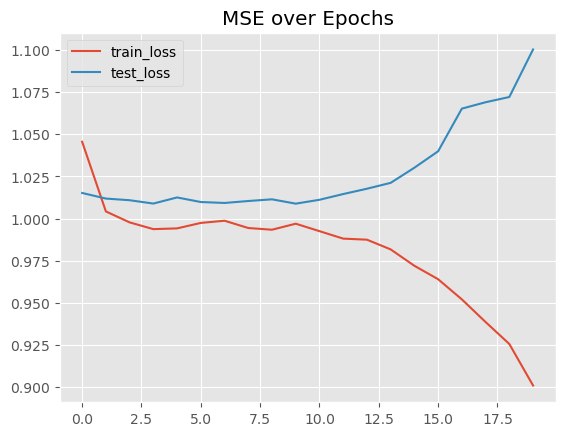

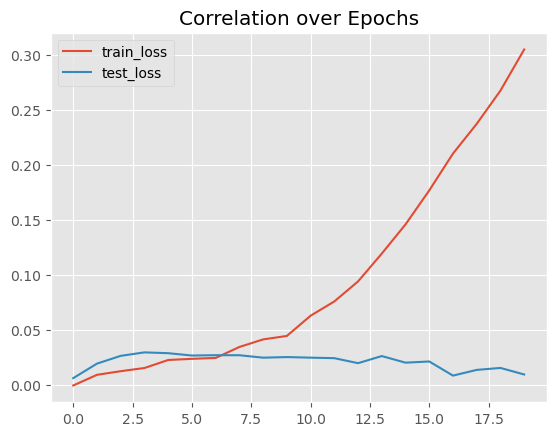

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:27<00:00,  1.35s/it]


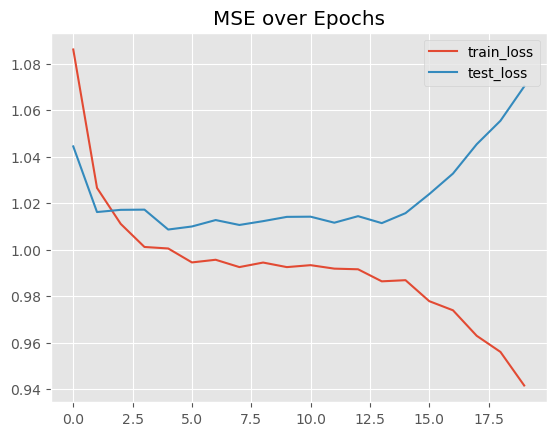

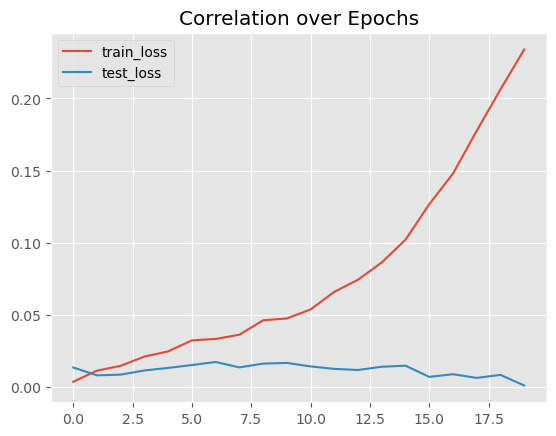

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:31<00:00,  1.56s/it]


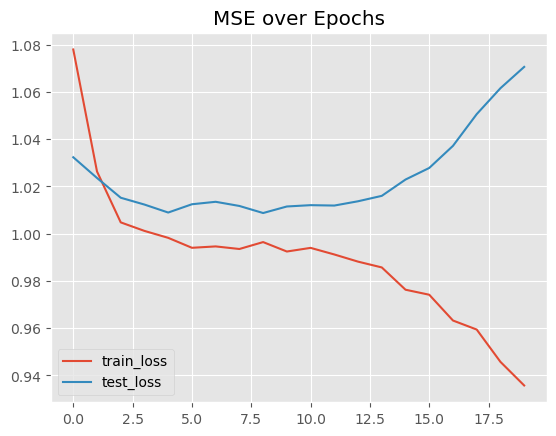

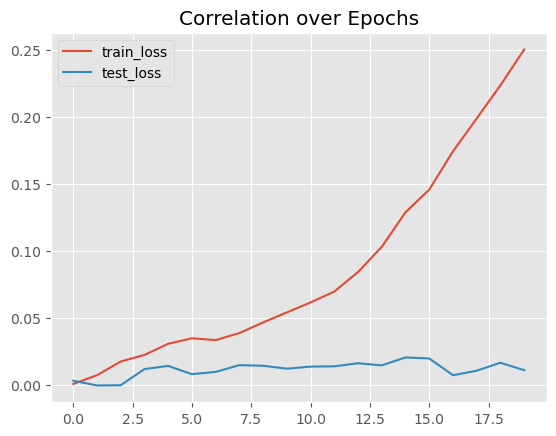

,true,optimal,shift,full_attention,deterministic_sparse,top_k_sparse
optimal,0.027,nan,nan,nan,nan,nan
shift,0.027,1.000,nan,nan,nan,nan
full_attention,0.380,0.094,0.094,nan,nan,nan
deterministic_sparse,0.372,0.154,0.154,0.286,nan,nan
top_k_sparse,0.288,0.173,0.173,0.306,0.355,nan
max_sparse,0.306,0.150,0.150,0.307,0.333,0.357


,true,optimal,shift,full_attention,deterministic_sparse,top_k_sparse
optimal,0.027,nan,nan,nan,nan,nan
shift,0.027,1.000,nan,nan,nan,nan
full_attention,0.009,0.084,0.084,nan,nan,nan
deterministic_sparse,-0.001,0.144,0.144,0.177,nan,nan
top_k_sparse,0.001,0.149,0.149,0.226,0.293,nan
max_sparse,0.017,0.146,0.146,0.230,0.255,0.303


In [27]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 10, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 10, device=device)


for c in [0.01]:
    @dataclass
    class Config:
        T: int = 3000
        n_ts: int = 10
        n_f: int = 20
        pct_zero_corr: float = 0.5
        split_conditional: float = 0.0
        split_shift: float = 1.0
        split_seasonal: float = 0.0
        split_cs: float = 0.0
        split_cs_shift: float = 0.0
        low_corr: float = c
        high_corr: float = c
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr
    )
    
    z.get_dataloader()
    for k in models_linear:
        models_linear[k].fit(z.train)
    
    # param for regularization
    lambda_l1_value = 0.5
    
    sparse_model = models.CustomBiDimensionalTransformerSparse(
        Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC',
        dropout=0.1, dim_feedforward=256, sparsify=None, nhead=1,
        lambda_l1=lambda_l1_value, roll_y=True
    ).to(device)
    
    # loss fct with l1 norm
    loss_fn = MSELossWithL1Sparsity(model=sparse_model, lambda_l1=lambda_l1_value)
    
    models_torch = {
        'full_attention': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TCTC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        'deterministic_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TCTC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        
        'top_k_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TCTC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
        ).to(device),
        
        'max_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TCTC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
        ).to(device),
        
    }


    models_torch = {
        k: torch_benchmarks.TorchWrapper(
            models_torch[k], 
            optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
            loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss()  # Use L1 loss for sparse model
        ) for k in models_torch
    }

    
    z.get_dataloader(n_rolling=10, roll_y=True)
    for k in models_torch:
        models_torch[k].fit(z.train, test=z.test, epochs=20)
    
    comp = benchmark_comparison.Comparator(
        models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch], 
        model_names=[k for k in models_linear] + [k for k in models_torch]
    )
    display(comp.correl(z, mode='train'))
    display(comp.correl(z, mode='test'))

Full attention matrix FIRST layer

In [28]:
pd.DataFrame(np.array(models_torch['full_attention'].model.blocks[0].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.444,0.556,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.471,0.317,0.212,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.183,0.488,0.213,0.116,0.000,0.000,0.000,0.000,0.000,0.000
4,0.033,0.095,0.521,0.251,0.100,0.000,0.000,0.000,0.000,0.000
5,0.016,0.024,0.118,0.534,0.250,0.057,0.000,0.000,0.000,0.000
6,0.037,0.020,0.020,0.093,0.543,0.200,0.088,0.000,0.000,0.000
7,0.013,0.025,0.011,0.009,0.098,0.604,0.179,0.061,0.000,0.000
8,0.013,0.013,0.014,0.009,0.021,0.121,0.545,0.188,0.075,0.000
9,0.029,0.008,0.024,0.046,0.011,0.022,0.123,0.458,0.189,0.090


Full attention matrix SECOND layer

In [36]:
pd.DataFrame(np.array(models_torch['full_attention'].model.blocks[2].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.664,0.336,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.396,0.409,0.195,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.165,0.248,0.470,0.116,0.000,0.000,0.000,0.000,0.000,0.000
4,0.097,0.170,0.218,0.400,0.115,0.000,0.000,0.000,0.000,0.000
5,0.109,0.073,0.067,0.187,0.397,0.166,0.000,0.000,0.000,0.000
6,0.089,0.055,0.057,0.145,0.238,0.308,0.108,0.000,0.000,0.000
7,0.061,0.056,0.058,0.080,0.079,0.203,0.341,0.122,0.000,0.000
8,0.039,0.053,0.112,0.060,0.048,0.087,0.245,0.255,0.101,0.000
9,0.044,0.036,0.060,0.064,0.032,0.043,0.071,0.241,0.361,0.046


Sparsity matrix with the max proba algorithm FIRST layer

In [37]:
pd.DataFrame(np.array(models_torch['max_sparse'].model.blocks[0].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.416,0.584,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.456,0.544,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.000,0.000,0.441,0.559,0.000,0.000,0.000,0.000,0.000,0.000
4,0.000,0.000,0.000,0.468,0.532,0.000,0.000,0.000,0.000,0.000
5,0.000,0.000,0.000,0.000,0.499,0.501,0.000,0.000,0.000,0.000
6,0.000,0.000,0.000,0.000,0.000,0.498,0.502,0.000,0.000,0.000
7,0.000,0.000,0.000,0.000,0.000,0.000,0.502,0.498,0.000,0.000
8,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.609,0.391,0.000
9,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.560,0.440


Sparsity matrix with the max proba algorithm SECOND layer

In [39]:
pd.DataFrame(np.array(models_torch['max_sparse'].model.blocks[2].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.525,0.475,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.497,0.503,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.000,0.000,0.547,0.453,0.000,0.000,0.000,0.000,0.000,0.000
4,0.000,0.000,0.000,0.571,0.429,0.000,0.000,0.000,0.000,0.000
5,0.000,0.000,0.000,0.000,0.495,0.505,0.000,0.000,0.000,0.000
6,0.000,0.000,0.000,0.000,0.000,0.498,0.502,0.000,0.000,0.000
7,0.000,0.000,0.000,0.000,0.000,0.000,0.504,0.496,0.000,0.000
8,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.608,0.392,0.000
9,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.590,0.410


In [ ]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 10, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 10, device=device)


records_train = []
records_test  = [] 

for k in range(10):
    records_train.append({})
    records_test.append({})
    
    @dataclass
    class Config:
        T: int = 3000
        n_ts: int = 10
        n_f: int = 20
        pct_zero_corr: float = 0.5
        split_conditional: float = 0.0
        split_shift: float = 1.0
        split_seasonal: float = 0.0
        split_cs: float = 0.0
        split_cs_shift: float = 0.0
        low_corr: float = c
        high_corr: float = c
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr
    )
    
    z.get_dataloader()
    for k in models_linear:
        models_linear[k].fit(z.train)
    
    # param for regularization
    lambda_l1_value = 0.5
    
    sparse_model = models.CustomBiDimensionalTransformerSparse(
        Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC',
        dropout=0.1, dim_feedforward=256, sparsify=None, nhead=1,
        lambda_l1=lambda_l1_value, roll_y=True
    ).to(device)
    
    # loss fct with l1 norm
    loss_fn = MSELossWithL1Sparsity(model=sparse_model, lambda_l1=lambda_l1_value)
    
    models_torch = {
        'full_attention': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TCTC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        'deterministic_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TCTC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        
        'top_k_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TCTC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
        ).to(device),
        
        'max_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TCTC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
        ).to(device)
    }


    models_torch = {
        k: torch_benchmarks.TorchWrapper(
            models_torch[k], 
            optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
            loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss()  
        ) for k in models_torch
    }

    
    z.get_dataloader(n_rolling=10, roll_y=True)
    for k in models_torch:
        models_torch[k].fit(z.train, test=z.test, epochs=20, plot=False)
        
        comp = benchmark_comparison.Comparator(models=[models_torch[k]], model_names=[k])

        
        corr_train = comp.correl(z, mode="train", return_values=True)
        corr_test  = comp.correl(z, mode="test",  return_values=True)

        train_corr = corr_train.loc[k, "optimal"]
        test_corr  = corr_test.loc[k, "optimal"]

        records_train[-1][k + '_train_corr'] = train_corr
        records_test[-1][k + '_test_corr'] = test_corr
        
    
    
    comp = benchmark_comparison.Comparator(
        models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch], 
        model_names=[k for k in models_linear] + [k for k in models_torch]
    )
    display(comp.correl(z, mode='train'))
    display(comp.correl(z, mode='test'))

 45%|█████████████████████████████████████████████████▌                                                            | 9/20 [00:14<00:15,  1.42s/it]

In [ ]:
table_train = pd.DataFrame(records_train)
table_test  = pd.DataFrame(records_test)

In [ ]:
display(pd.concat([table_test.quantile([0.1, 0.9]), table_test.aggregate(['min', 'max', 'mean', 'std'])]).T.style.background_gradient().format(precision=4))

In [ ]:
display(pd.concat([table_train.quantile([0.1, 0.9]), table_train.aggregate(['min', 'max', 'mean', 'std'])]).T.style.background_gradient().format(precision=4))

## Cross-sectionnal study

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:16<00:00,  1.19it/s]


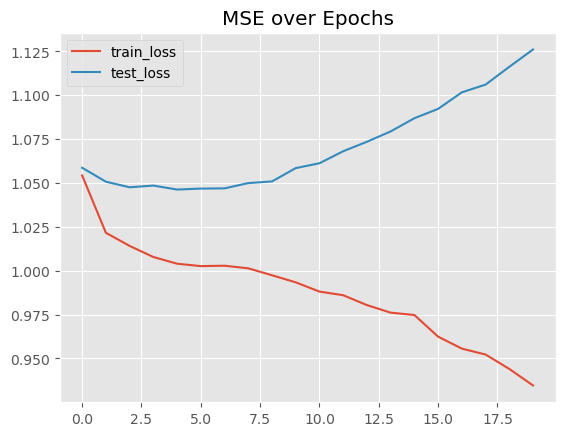

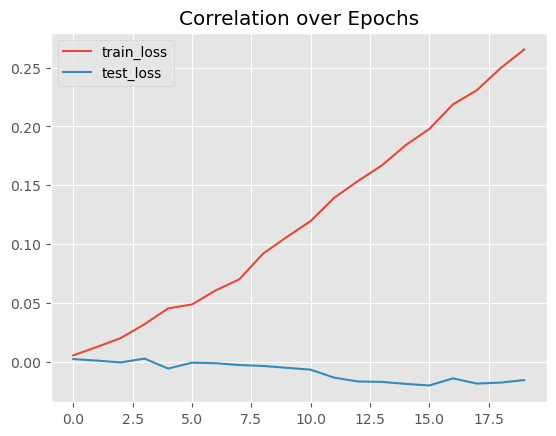

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:14<00:00,  1.41it/s]


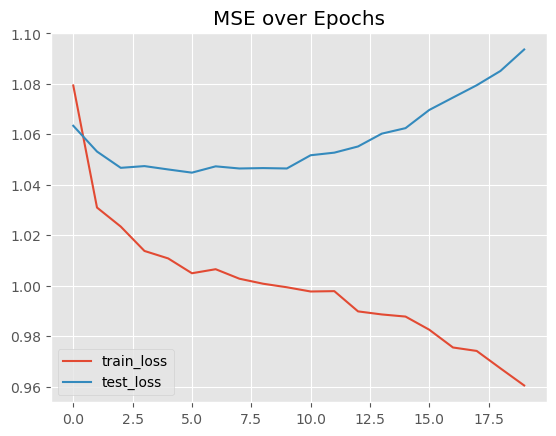

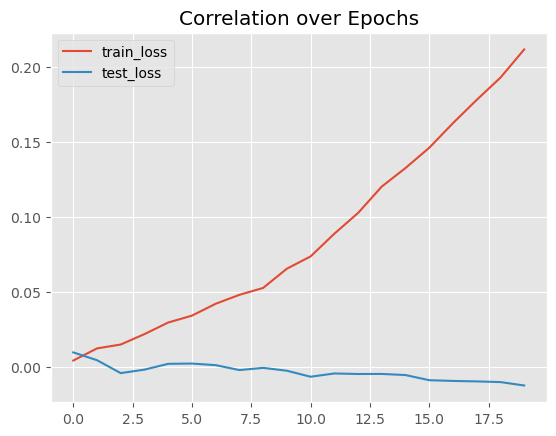

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:14<00:00,  1.38it/s]


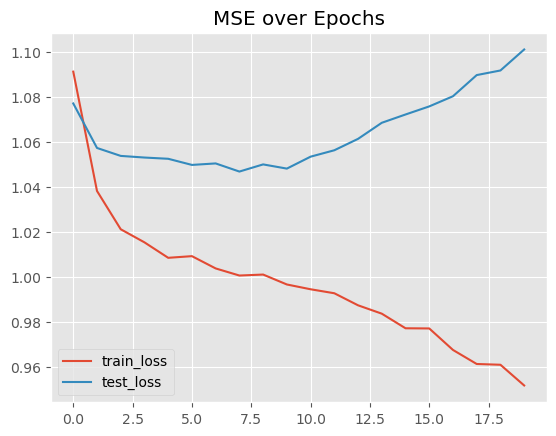

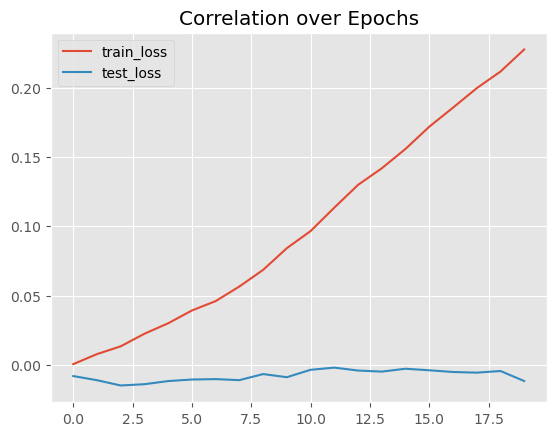

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:14<00:00,  1.36it/s]


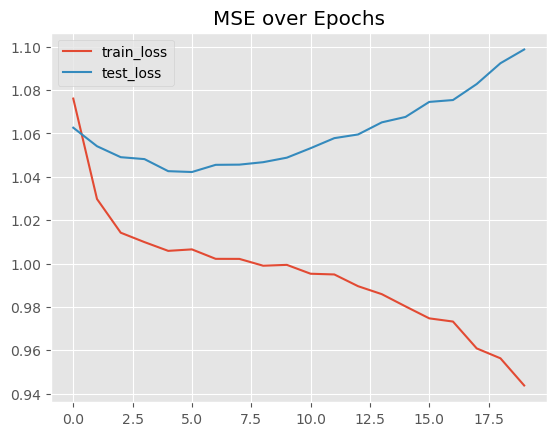

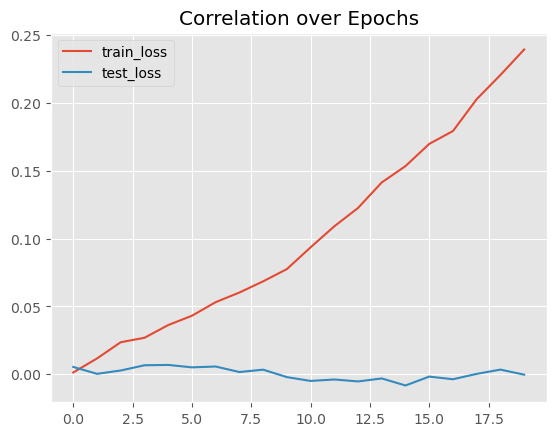

,true,optimal,cs,lasso,full_attention,deterministic_sparse,top_k_sparse
optimal,0.035,nan,nan,nan,nan,nan,nan
cs,0.035,1.000,nan,nan,nan,nan,nan
lasso,0.025,0.011,0.011,nan,nan,nan,nan
full_attention,0.304,0.028,0.028,0.079,nan,nan,nan
deterministic_sparse,0.250,0.059,0.059,0.127,0.286,nan,nan
top_k_sparse,0.265,0.032,0.032,0.167,0.276,0.326,nan
max_sparse,0.278,0.057,0.057,0.134,0.301,0.326,0.281


,true,optimal,cs,lasso,full_attention,deterministic_sparse,top_k_sparse
optimal,0.043,nan,nan,nan,nan,nan,nan
cs,0.043,1.000,nan,nan,nan,nan,nan
lasso,0.004,-0.002,-0.002,nan,nan,nan,nan
full_attention,-0.009,0.018,0.018,0.076,nan,nan,nan
deterministic_sparse,-0.007,0.051,0.051,0.134,0.235,nan,nan
top_k_sparse,-0.004,0.035,0.035,0.156,0.225,0.275,nan
max_sparse,-0.000,0.038,0.038,0.127,0.240,0.262,0.232


In [41]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 10, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 10, device=device)


for c in [0.01]:
    @dataclass
    class Config:
        T: int = 3000
        n_ts: int = 10
        n_f: int = 20
        pct_zero_corr: float = 0.5
        split_conditional: float = 0.0
        split_shift: float = 0.0
        split_seasonal: float = 0.0
        split_cs: float = 1.0
        split_cs_shift: float = 0.0
        low_corr: float = c
        high_corr: float = c
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr
    )
    
    z.get_dataloader()
    for k in models_linear:
        models_linear[k].fit(z.train)
    
    # param for regularization
    lambda_l1_value = 0.5
    
    sparse_model = models.CustomBiDimensionalTransformerSparse(
        Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC',
        dropout=0.1, dim_feedforward=256, sparsify=None, nhead=1,
        lambda_l1=lambda_l1_value, roll_y=True
    ).to(device)
    
    # loss fct with l1 norm
    loss_fn = MSELossWithL1Sparsity(model=sparse_model, lambda_l1=lambda_l1_value)
    
    models_torch = {
        'full_attention': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        'deterministic_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        
        'top_k_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
        ).to(device),
        
        'max_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
        ).to(device),
        
    }


    models_torch = {
        k: torch_benchmarks.TorchWrapper(
            models_torch[k], 
            optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
            loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss()  # Use L1 loss for sparse model
        ) for k in models_torch
    }

    
    z.get_dataloader(n_rolling=10, roll_y=True)
    for k in models_torch:
        models_torch[k].fit(z.train, test=z.test, epochs=20)
    
    comp = benchmark_comparison.Comparator(
        models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch], 
        model_names=[k for k in models_linear] + [k for k in models_torch]
    )
    display(comp.correl(z, mode='train'))
    display(comp.correl(z, mode='test'))